# Домашнее задание №4: исследование линейной регрессии
---
## 1. Первичный анализ данных (описание датасета)
### Price of Used Toyota Corolla Cars

**Ссылка для скачивания:**  
https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

### О датасете
- **1436 записей**, 38 признаков (35 числовых + 3 категориальных)
- **Целевая переменная:** `Price` - Цена продажи подержанного автомобиля.
- **Описание признаков:**

| Признак | Описание | Тип |
|---------|----------|-----|
| **Id** | Уникальный идентификатор | Числовой (int) |
| **Model** | Модель Toyota Corolla | Категориальный (str) |
| **Price** | Цена автомобиля | Числовой (int) - ЦЕЛЕВАЯ |
| **Age_08_04** | Возраст авто в месяцах на 08.2004 | Числовой (int) |
| **Mfg_Month** | Месяц производства | Числовой (int) |
| **Mfg_Year** | Год производства | Числовой (int) |
| **KM** | Пробег в километрах | Числовой (int) |
| **Fuel_type** | Тип топлива (Petrol, Diesel, CNG) | Категориальный (str) |
| **HP** | Лошадиные силы | Числовой (int) |
| **Met_Color** | Металлик (0/1) | Бинарный (int) |
| **Color** | Цвет кузова | Категориальный (str) |
| **Automatic** | Автоматическая КПП (0/1) | Бинарный (int) |
| **CC** | Объем двигателя (см³) | Числовой (int) |
| **Doors** | Количество дверей | Числовой (int) |
| **Cylinders** | Количество цилиндров | Числовой (int) |
| **Gears** | Количество передач | Числовой (int) |
| **Quarterly** | Ежеквартальный налог | Числовой (int) |
| **Weight** | Вес автомобиля | Числовой (int) |
| **Mfr_Guarantee** | Гарантия производителя (0/1) | Бинарный (int) |
| **BOVAG_Guarantee** | Гарантия BOVAG (0/1) | Бинарный (int) |
| **Guarantee_Period** | Срок гарантии (мес.) | Числовой (int) |
| **ABS** | Антиблокировочная система (0/1) | Бинарный (int) |
| **Airbag_1** | Подушка безопасности 1 (0/1) | Бинарный (int) |
| **Airbag_2** | Подушка безопасности 2 (0/1) | Бинарный (int) |
| **Airco** | Кондиционер (0/1) | Бинарный (int) |
| **Automatic_airco** | Автокондиционер (0/1) | Бинарный (int) |
| **Boardcomputer** | Бортовой компьютер (0/1) | Бинарный (int) |
| **CD_Player** | CD-плеер (0/1) | Бинарный (int) |
| **Central_Lock** | Центральный замок (0/1) | Бинарный (int) |
| **Powered_Windows** | Электростеклоподъемники (0/1) | Бинарный (int) |
| **Power_Steering** | Гидроусилитель руля (0/1) | Бинарный (int) |
| **Radio** | Радио (0/1) | Бинарный (int) |
| **Mistlamps** | Противотуманные фары (0/1) | Бинарный (int) |
| **Sport_Model** | Спортивная модель (0/1) | Бинарный (int) |
| **Backseat_Divider** | Разделитель заднего сиденья (0/1) | Бинарный (int) |
| **Metallic_Rim** | Металлические диски (0/1) | Бинарный (int) |
| **Radio_cassette** | Радиокассетный плеер (0/1) | Бинарный (int) |
| **Parking_Assistant** | Парктроник (0/1) | Бинарный (int) |
| **Tow_Bar** | Фаркоп (0/1) | Бинарный (int) |

- **Пропусков нет - все 1436 записей содержат полные данные по всем признакам**

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time


# Настройка отображения всех столбцов
pd.set_option('display.max_columns', None)  # Показывать все колонки
pd.set_option('display.max_rows', None)     # Показывать все строки
pd.set_option('display.width', None)        # Авто-ширина
pd.set_option('display.max_colwidth', None) # Полное содержимое ячеек

df = pd.read_csv("ToyotaCorolla.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

- **Первые 5 строк**

In [328]:
df.head()

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0


- **Базовые статистики:**

In [329]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,4.033426,4.0,5.026462,87.122563,1072.45961,0.409471,0.895543,3.815460,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,0.218663,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,0.952677,0.0,0.188510,41.128611,52.64112,0.491907,0.305959,3.011025,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,0.413483,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,2.000000,4.0,3.000000,19.000000,1000.00000,0.000000,0.000000,3.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,3.000000,4.0,5.000000,69.000000,1040.00000,0.000000,1.000000,3.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,4.000000,4.0,5.000000,85.000000,1070.00000,0.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,5.000000,4.0,5.000000,85.000000,1085.00000,1.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,5.000000,4.0,6.000000,283.000000,1615.00000,1.000000,1.000000,36.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [330]:
df[df["CC"] == 16000]

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
80,81,TOYOTA Corolla 1.6 5drs 1 4/5-Doors,18950,25,8,2002,20019,Petrol,110,1,Blue,1,16000,5,4,5,100,1180,0,0,3,1,1,1,1,1,0,1,1,1,1,0,0,0,0,0,0,0,0


CC = 16000 $см^3$, явно написали лишний 0, исправим

In [331]:
df.loc[df["CC"] == 16000, 'CC'] = 1600

In [332]:
df.describe()

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.0,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1566.827994,4.033426,4.0,5.026462,87.122563,1072.45961,0.409471,0.895543,3.815460,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,0.218663,0.580084,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,187.182436,0.952677,0.0,0.188510,41.128611,52.64112,0.491907,0.305959,3.011025,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,0.413483,0.493717,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.000000,2.000000,4.0,3.000000,19.000000,1000.00000,0.000000,0.000000,3.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.000000,3.000000,4.0,5.000000,69.000000,1040.00000,0.000000,1.000000,3.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.000000,4.000000,4.0,5.000000,85.000000,1070.00000,0.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.000000,5.000000,4.0,5.000000,85.000000,1085.00000,1.000000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,2000.000000,5.000000,4.0,6.000000,283.000000,1615.00000,1.000000,1.000000,36.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [333]:
df.describe(include=["object", "string"])

,Model,Fuel_Type,Color
count,1436,1436,1436
unique,319,3,10
top,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-Doors,Petrol,Grey
freq,109,1264,301


**Кодирование категориальных признаков**\
Перед кодироанием удалим признак `Model` , `Cylinders` и `Id` так они несут малую информативность, а из-за большого кол-ва уникальных значений `Model`, количество признаков после кодирования очень сильно увеличится. Все данные,которые есть в `Model` можно получить из других признаков.

In [334]:
df = df.drop('Model', axis=1)
df = df.drop('Cylinders', axis=1)
df = df.drop('Id', axis=1)

In [335]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

print("После кодирования:")
df.head()

После кодирования:


,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,Doors,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Color_Beige,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,13500,23,10,2002,46986,90,1,0,2000,3,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
1,13750,23,10,2002,72937,90,1,0,2000,3,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,13950,24,9,2002,41711,90,1,0,2000,3,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0
3,14950,26,7,2002,48000,90,0,0,2000,3,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0
4,13750,30,3,2002,38500,90,0,0,2000,3,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0


**Построим матрицу корреляции и выведем топ-признаки**

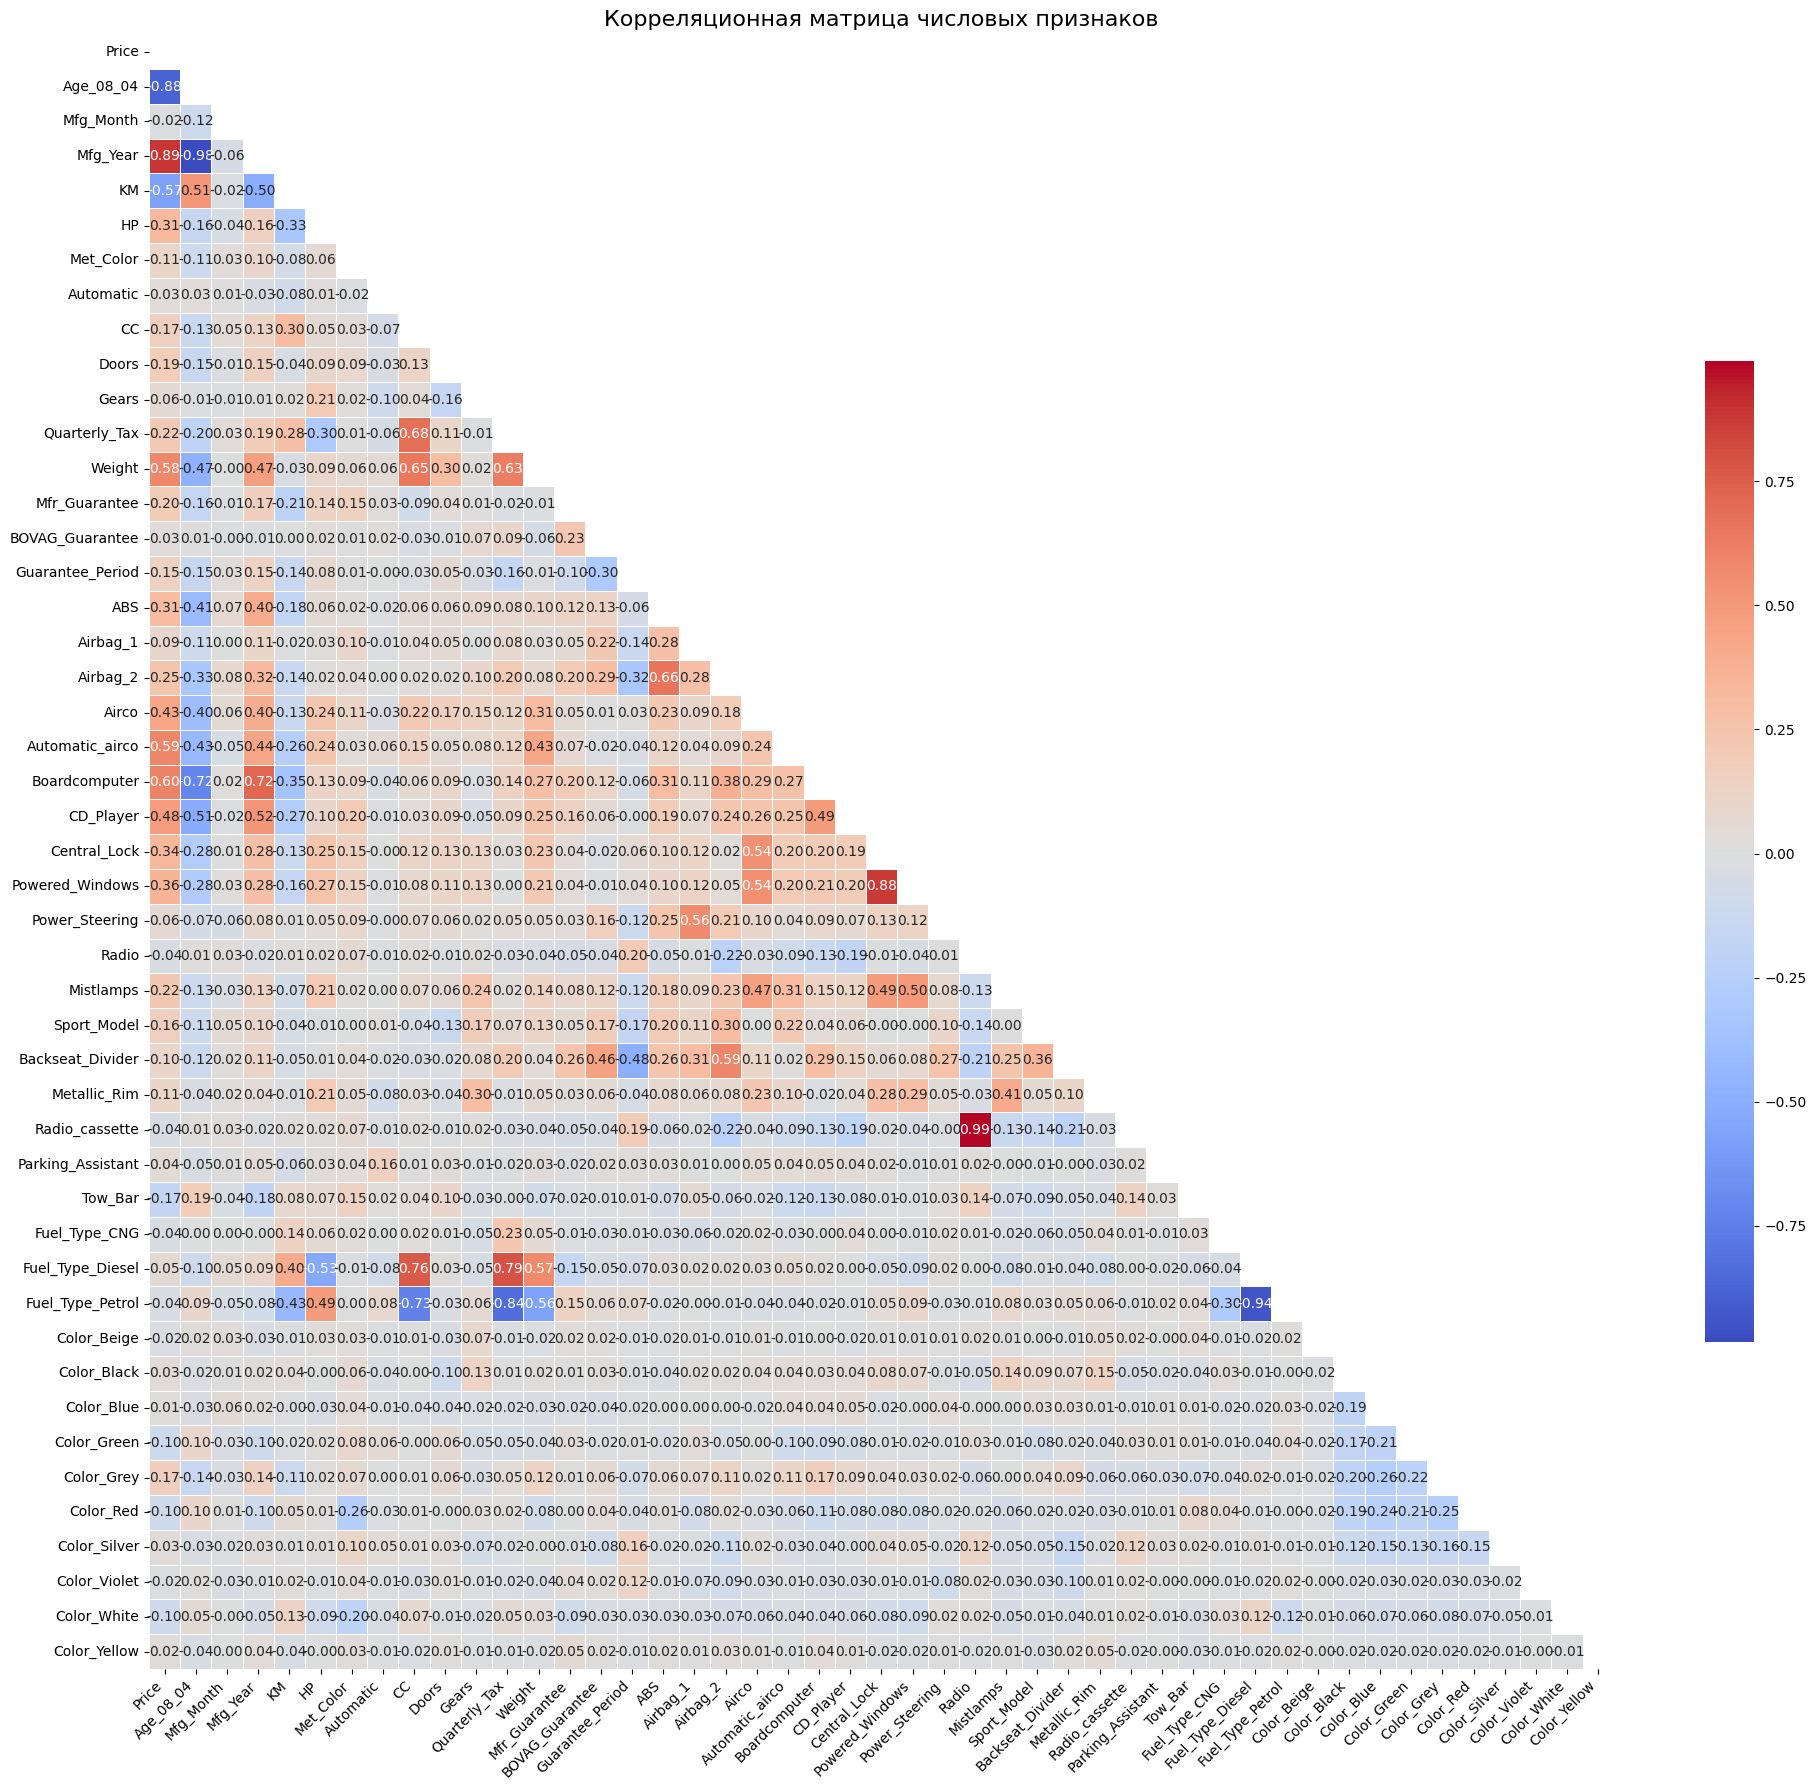

In [336]:
# Построение корреляционной матрицы
plt.figure(figsize=(20, 18))

correlation_matrix = df.select_dtypes(include=[np.number]).corr()

mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, cbar_kws={"shrink": .6})
plt.title('Корреляционная матрица числовых признаков', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Корреляция признаков с целевой переменной:
Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Color_Grey           0.169947
CC                   0.165067
Sport_Model          0.164121
Guarantee_Period     0.146627
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Fuel_Type_Diesel     0.054084
Parking_Assistant    0.044375
Color_Black          0.034896
Automatic            0.033081
Color_Silver         0.028562
BOVAG_Guarantee      0.028

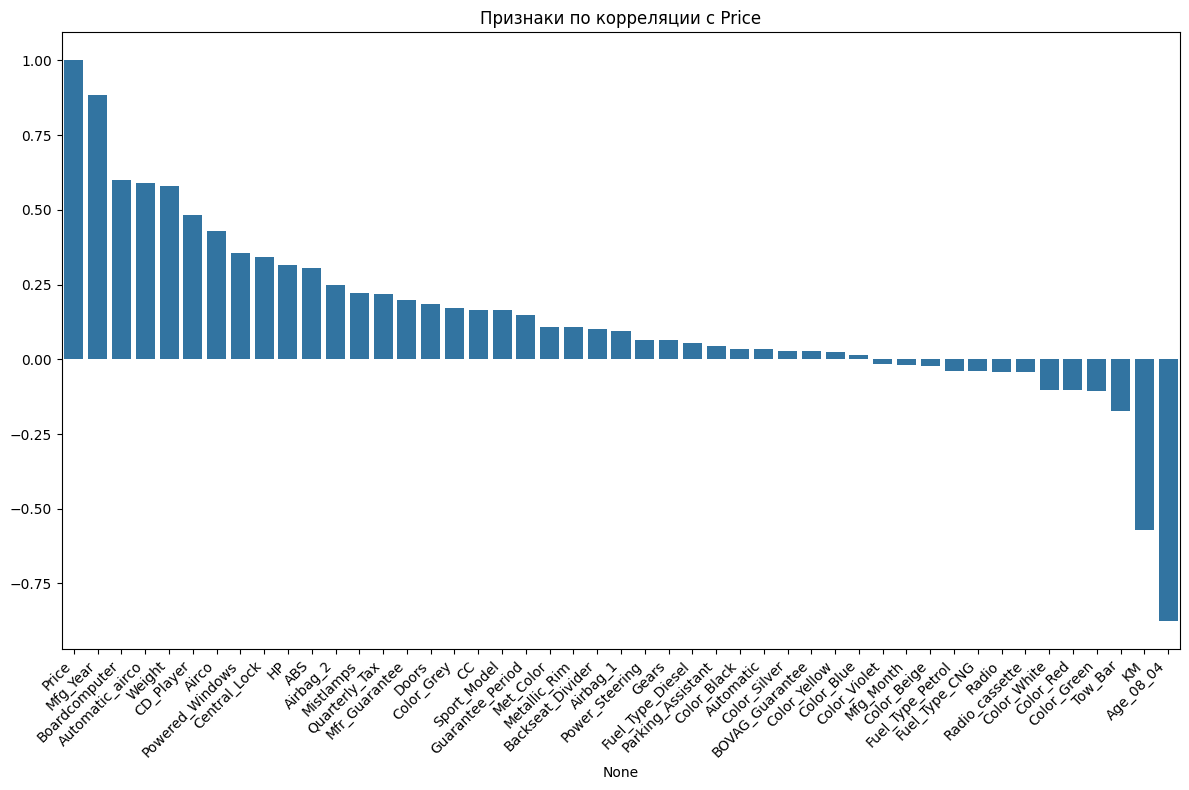

In [337]:
# Расчет корреляции признаков с целевой переменной
target_correlation = correlation_matrix['Price'].sort_values(ascending=False)
print("\nКорреляция признаков с целевой переменной:")
print(target_correlation)

# Визуализация топ-10 признаков по корреляции с целевой переменной
plt.figure(figsize=(12, 8))
sns.barplot(x=target_correlation.index[:], y=target_correlation.values[:])
plt.title('Признаки по корреляции с Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Как я предобрабатывал данные?**\
На этапе первичного анализа я загрузил данные и проверил их на наличие пропусков, и выбросов с помощью функций `info()`, `describe()`. Категориальные признаки кодированы с помощью `pd.get_dummies`.

**Что понял, проведя EDA?**\
В ходе разведочного анализа выяснилось, что датасет содержит множество бинарных признаков (опции автомобиля), а также несколько категориальных переменных (`Model`, `Fuel_type`, `Color`). Обнаружена сильная корреляция между возрастом автомобиля (`Age_08_04`) и годом выпуска (`Mfg_Year`), а также наличие константного признака `Cylinders`, не несущего информации. Целевая переменная `Price`.

---
## 2. Работа с признаками (Feature Engineering)

In [338]:
features_to_drop = [
    'Id',
    
    # 3. Дублиткаты
    'Mfg_Year',
    
    # 4. цвета
    'Color_Grey', 'Color_Black', 'Color_Silver', 'Color_Yellow',
    'Color_Blue', 'Color_Violet', 'Color_Beige', 'Color_White',
    'Color_Red', 'Color_Green',
    
    # 5. Слабые признаки
    'Parking_Assistant', 'BOVAG_Guarantee', 'Mfg_Month',
    'Fuel_Type_Petrol', 'Fuel_Type_CNG', 'Radio', 'Radio_cassette','Automatic'
]

features_to_drop = [f for f in features_to_drop if f in df.columns]
df = df.drop(features_to_drop, axis=1)

In [339]:
df['KM_per_year'] = df['KM'] / (df['Age_08_04'] / 12)

df['HP_per_ton'] = df['HP'] / (df['Weight'] / 1000)

In [340]:
# Список всех бинарных опций (кроме цвета и топлива)
option_cols = ['ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco', 
               'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
               'Power_Steering', 'Mistlamps', 'Sport_Model', 
               'Backseat_Divider', 'Metallic_Rim', 'Tow_Bar', 'Mfr_Guarantee']

# Общее количество опций
df['Total_Options'] = df[option_cols].sum(axis=1)
# Чем больше опций, тем выше класс комплектации

In [341]:
df.describe()

,Price,Age_08_04,KM,HP,Met_Color,CC,Doors,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Tow_Bar,Fuel_Type_Diesel,KM_per_year,HP_per_ton,Total_Options
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,10730.824513,55.947075,68533.259749,101.502089,0.674791,1566.827994,4.033426,5.026462,87.122563,1072.45961,0.409471,3.815460,0.81337,0.970752,0.722841,0.508357,0.056407,0.294568,0.218663,0.580084,0.561978,0.977716,0.256964,0.300139,0.770195,0.204735,0.277855,0.107939,15018.671398,94.783313,7.924095
std,3626.964585,18.599988,37506.448872,14.981080,0.468616,187.182436,0.952677,0.188510,41.128611,52.64112,0.491907,3.011025,0.38975,0.168559,0.447751,0.500104,0.230786,0.456007,0.413483,0.493717,0.496317,0.147657,0.437111,0.458478,0.420854,0.403649,0.448098,0.310411,7640.043711,13.686590,3.016647
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,3.000000,19.000000,1000.00000,0.000000,3.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.157895,58.108108,0.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,5.000000,69.000000,1040.00000,0.000000,3.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,10261.791452,84.729064,6.000000
50%,9900.000000,61.000000,63389.500000,110.000000,1.000000,1600.000000,4.000000,5.000000,85.000000,1070.00000,0.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,13596.676471,101.382488,8.000000
75%,11950.000000,70.000000,87020.750000,110.000000,1.000000,1600.000000,5.000000,5.000000,85.000000,1085.00000,1.000000,3.000000,1.00000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,18031.206939,103.286385,10.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,2000.000000,5.000000,6.000000,283.000000,1615.00000,1.000000,36.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67813.953488,162.025316,16.000000


**Как я работал с признаками?**\
Был проведен отбор признаков на основе корреляционного анализа, удалены дублирующие, слабокоррелирующие и неинформативные признаки, после чего созданы новые комбинированные признаки для улучшения качества модели.

**Какие признаки я добавил / изменил и почему?**\
Добавлены три новых признака: `KM_per_year` (интенсивность использования), `HP_per_ton` (удельная мощность) и `Total_Options` (общий уровень оснащения), так как они отражают комплексные характеристики автомобиля, которые лучше предсказывают цену, чем исходные признаки по отдельности.

**Какие признаки я удалил и почему?**\
Удалены `Id` (искусственный идентификатор), все цвета (слабая корреляция с ценой), а также слабые признаки (`Parking_Assistant`, `BOVAG_Guarantee`, `Mfg_Month`, `Radio`, `Radio_cassette`, `Automatic` и дублирующие типы топлива), так как они не влияют на целевую переменную.

---
## 3. Разделение выборки

In [342]:
X = df.drop("Price", axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Как именно я разделил выборку?**\
Выборка была разделена на обучающую (70%) и тестовую (30%) с помощью `train_test_split` с параметром `random_state=42` для воспроизводимости результатов.

**Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?**\
Разделение данных необходимо для объективной оценки качества модели: если обучать и проверять модель на одних и тех же данных, мы получим оптимистичную оценку (переобучение), так как модель просто запомнит ответы вместо того чтобы научиться обобщать закономерности. Тестовая выборка имитирует новые, неизвестные модели данные и позволяет понять, насколько хорошо модель будет работать в реальных условиях.

---
## 4. Обучение моделей

In [343]:
# 1. Базовая линейная регрессия
start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - RMSE: {lr_rmse:.2f}, R2: {lr_r2:.4f}, Время: {lr_time:.4f} сек")

# 2. Ridge регрессия (с подбором alpha)


start_time = time.time()
ridge = Ridge()
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)
ridge_time = time.time() - start_time

y_pred_ridge = ridge_grid.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regression - RMSE: {ridge_rmse:.2f}, R2: {ridge_r2:.4f}, Время: {ridge_time:.4f} сек")
print(f"Лучший alpha: {ridge_grid.best_params_}")

# 3. Lasso регрессия (с подбором alpha)

# Масштабируем данные
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start_time = time.time()
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000, tol=0.001)
lasso_cv.fit(X_train_scaled, y_train)
lasso_cv_time = time.time() - start_time

y_pred_lassocv = lasso_cv.predict(X_test_scaled)

lassocv_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lassocv))
lassocv_r2 = r2_score(y_test, y_pred_lassocv)

print(f"LassoCV - RMSE: {lassocv_rmse:.2f}, R2: {lassocv_r2:.4f}, Время: {lasso_cv_time:.4f} сек")
print(f"Лучший alpha: {lasso_cv.alpha_:.2f}")


Linear Regression - RMSE: 1182.91, R2: 0.8995, Время: 0.0045 сек
Ridge Regression - RMSE: 1180.75, R2: 0.8999, Время: 0.1649 сек
Лучший alpha: {'alpha': 1}
LassoCV - RMSE: 1184.60, R2: 0.8992, Время: 0.0797 сек
Лучший alpha: 14.62


**Как проходило обучение моделей?**
Линейная регрессия обучилась за 0.0045  сек, Ridge с подбором гиперпараметров за 0.1649 сек, а Lasso сошелся за 0.0797 сек.

**Сравнение скорости:**
Линейная регрессия оказалась самой быстрой, Ridge с GridSearchCV - самой медленной, а LassoCV занял промежуточное положение

---

## 5. Оценка качества и сравнение моделей

In [344]:
def calculate_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MSE': f'{mse:.2f}',
        'RMSE': f'{rmse:.2f}',
        'MAE': f'{mae:.2f}',
        'R2': f'{r2:.4f}'
    }

results = []

results.append(calculate_metrics(y_test, y_pred_lr, 'Linear Regression'))

results.append(calculate_metrics(y_test, y_pred_ridge, 'Ridge Regression'))

results.append(calculate_metrics(y_test, y_pred_lassocv, 'LassoCV'))

results_df = pd.DataFrame(results)
print("=== Метрики на тестовой выборке ===\n")
print(results_df.to_string(index=False))

print("\n=== Проверка переобучения ===\n")

y_train_pred = lr.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print(f"Linear Regression:")
print(f"  Train RMSE: {train_rmse:.2f}, Train R2: {train_r2:.4f}")
print(f"  Test  RMSE: {lr_rmse:.2f}, Test  R2: {lr_r2:.4f}")
print(f"  Разница RMSE: {abs(train_rmse - lr_rmse):.2f}")
print(f"  Разница R2: {abs(train_r2 - lr_r2):.4f}")

y_train_pred_ridge = ridge_grid.predict(X_train)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)

print(f"\nRidge Regression:")
print(f"  Train RMSE: {train_rmse_ridge:.2f}, Train R2: {train_r2_ridge:.4f}")
print(f"  Test  RMSE: {ridge_rmse:.2f}, Test  R2: {ridge_r2:.4f}")
print(f"  Разница RMSE: {abs(train_rmse_ridge - ridge_rmse):.2f}")
print(f"  Разница R2: {abs(train_r2_ridge - ridge_r2):.4f}")

y_train_pred_lasso = lasso_cv.predict(X_train_scaled)
train_rmse_lasso = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
train_r2_lasso = r2_score(y_train, y_train_pred_lasso)

print(f"\nLassoCV:")
print(f"  Train RMSE: {train_rmse_lasso:.2f}, Train R2: {train_r2_lasso:.4f}")
print(f"  Test  RMSE: {lassocv_rmse:.2f}, Test  R2: {lassocv_r2:.4f}")
print(f"  Разница RMSE: {abs(train_rmse_lasso - lassocv_rmse):.2f}")
print(f"  Разница R2: {abs(train_r2_lasso - lassocv_r2):.4f}")

=== Метрики на тестовой выборке ===

            Model        MSE    RMSE    MAE     R2
Linear Regression 1399279.41 1182.91 838.30 0.8995
 Ridge Regression 1394177.58 1180.75 837.83 0.8999
          LassoCV 1403288.55 1184.60 824.76 0.8992

=== Проверка переобучения ===

Linear Regression:
  Train RMSE: 1124.99, Train R2: 0.9012
  Test  RMSE: 1182.91, Test  R2: 0.8995
  Разница RMSE: 57.92
  Разница R2: 0.0017

Ridge Regression:
  Train RMSE: 1125.09, Train R2: 0.9012
  Test  RMSE: 1180.75, Test  R2: 0.8999
  Разница RMSE: 55.67
  Разница R2: 0.0013

LassoCV:
  Train RMSE: 1144.44, Train R2: 0.8978
  Test  RMSE: 1184.60, Test  R2: 0.8992
  Разница RMSE: 40.17
  Разница R2: 0.0014


**1. Какие метрики я использовали для сравнения моделей?**
Для сравнения моделей использовались RMSE, MAE и R2: RMSE выбран, поскольку он штрафует большие ошибки сильнее MAE, что важно при оценке стоимости автомобиля, а R2 показывает долю дисперсии цены, объясненную моделью (в нашем случае 90%).

**2. На какой части выборки я считал метрики?**
Метрики рассчитывались на тестовой выборке (30% данных), которая не участвовала в обучении, что подтверждается расчетами RMSE и R2 именно для y_test.

**3. Какая модель по итогу справилась лучше?**
Ridge показала лучший результат с RMSE = 1180.75 и R2 = 0.8999, незначительно опередив Линейную регрессию и Lasso по точности предсказаний.

**4. Насколько хорошие получились результаты?**
Результаты хорошие: модель объясняет 90% вариации цен (R2 = 0.90), а средняя ошибка предсказания (RMSE = 1180) составляет около 10-11% от средней цены автомобиля.

**5. Чем докажете, что ваша модель не переобучилась?**
Отсутствие переобучения подтверждается близостью метрик на обучающей и тестовой выборках: разница R2 составляет всего 0.0013 для Ridge регрессии, а разница RMSE - 55.67, что говорит о хорошей обобщающей способности модели.